<style>
    /* Targets the code blocks */
    pre, code, .jp-CodeCell, .jp-InputArea pre {
        font-size: 10px !important; 
        line-height: 1.2 !important;
    }
</style>

## Final Synthesis and Reflection
The overarching objective of this project was to critique and expand upon the methodology established by Pichl et al., who demonstrated that inferring "listening contexts" from human-generated playlist names can improve recommendation accuracy. Rather than accepting their geometric K-Means baseline, we embarked on an exploration of how these musical contexts are best defined and utilised. Across the three phases, we transitioned from geometric partitioning to topological network modelling and finally intra-cluster pattern mining. In this section, we consolidate our findings across the three parts and critically reassess our own methodology and assumptions, arriving at a definitive conclusion on how the semantics of human musical curation is best abstracted.

### Final Evaluation and Comparative Analysis
Our investigation started by implementing Pichl et al's original approach: K-Means clustering, to serve as our baseline. However we quickly saw its limitations. Text data from short playlist names is incredibly messy and sparse in a TF-IDF matrix. Because K-Means tries to mathematically force all data into rigid, spherical groups, it ended up lumping a massive amount of unrelated playlists into one giant, noisy cluster (what we termed the "gravity well"). As a result, its predictive accuracy was modest, peaking at a Top-1 score of around 0.65. To see if a different clustering strategy would help, we tested BIRCH, a bottom-up hierarchical model. BIRCH performed notably better, which we attribute exactly to this bottom-up approach, isolating noise in branches rather than dragging main clusters off center. Despite the improvement, both algorithms were, among other things, hypothesised to struggle from our fundamental data structure in high dimensional sparse space. This led to an investigation of the performance of the algorithms in reduced feature space, which proved beneficial for K-Means performance, and the transition from geometric clustering to graph-based clustering.

Building upon the geometric limitations hypothesised and investigated in phase 1, we transformed out dataset into a k-NN graph. In this new topological space, defined by only the strongest local similarities, we believed to have tackled a lot of the problems demonstrated in part 1.  We turned our attention to testing two opposing boundaries: Louvain (bottom-up community detection) and Spectral Clustering (top-down mathematical partitioning). The results proved a drastic improvement, with Top-1 scores leaping to around 0.9-0.92, however much of this is also attributed to the higher number of clusters, as we dive deeper into in the next section. Comparing the two algorithms, Spectral Clustering demonstrated an advantage, indicating a global boundary clustering approach is perhaps more effective for a more reliable and resilient semantic partitioning. We further investigated if we could refine the network representation even further using a M-KNN approach. Surprisingly, this approach perhaps became too strict, isolating nodes and losing information, leading to lower scores.

Finally, in Phase 3, we extended our evaluation beyond simply measuring cluster quality via Collaborative Filtering (CF). We implemented FP-Growth pattern mining within our clusters to extract deterministic track associations, based on the idea that co-occurrence rules might outperform generalized alignment. However, integrating these rules resulted in a stalemate, where our rules seemingly proved too diluted to make an impact, but not good enough to expand. To break this redundancy, we pivoted our strategy to filter by **Lift** ($> 2.0$), purposefully rejecting high-support rules in favour of niche track correlations. Both the standard and Lift-filtered hybrid models performed worse than the pure CF baseline. Overall, the results in this phase points towards a concrete problems in our partitions, where the playlist name clusterings don't correspond to high enough song cohesion to make reliable rules for the recommendation engine.

### Discussion of Methodology and Pipeline
Throughout the process, we've concluded that some of the assumptions presented by Pichl et al. integrated into our pipeline should perhaps be questioned more critically.

#### The Pichl et al. Evaluation Baseline
We adopted the evaluation methodology of Pichl et al., which relies on a proxy task: evaluating the semantic quality of our clusters based on their utility in a track-level Collaborative Filtering scenario. We must critically question whether this $F_{0.1}$ precision-based metric is a true reflection of clustering success. 

The core limitation of this approach is that it attempts to validate contextual intent (what the user named the playlist) using curatorial overlap (the exact tracks the user actually added). This assumes that contextual equivalence strictly translates to identical musical tastes. For instance, two users may curate semantically identical playlists labelled "Gym Motivation", completely validating the text-mining algorithm that clustered them together. However, if one user populates their playlist with 80s Rock and the other with modern EDM, the Jaccard-based recommender will find zero overlap, heavily penalizing the cluster's score. Consequently, the evaluation inherently penalizes musically diverse contexts while heavily biasing generic mainstream clusters that naturally share popular tracks. Therefore, the clustering algorithms might actually be performing better at context-discovery than the numbers suggest. 

Future methodologies should incorporate intrinsic semantic evaluation, such as measuring Topic Coherence among the grouped names, and/or expand recommendation metrics beyond precision to include novelty and serendipity (Kaminskas & Bridge, 2016), ensuring that contextual clustering is evaluated on its actual semantic merit.

#### Preprocessing
While our preprocessing pipeline proved successful in many aspects, we must conclude that the traditional approach of cascading filters and dictionary expansions is fundamentally flawed for short, user-generated text. We hypothesise that in attempt to clean the data, we degraded the semantic quality. This created a classic 'garbage in, garbage out' scenario, which severely limited the clustering algorithms' ability to find natural structures.

Firstly, the strict application of Stop-word Filtering frequently resulted in critical information loss. Furthermore, building a universally generalizable named entity filter for the fluid, slang-heavy domain of music curation proved practically impossible. In many cases, playlist names were reduced to disjointed, meaningless tokens, or became completely empty strings that had to be dropped entirely.

Second, as mentioned previously, our reliance on WordNet for Feature Expansion was a brute-force attempt to patch the sparsity caused by the filtering steps. This methodology relies on the idea that injecting dictionary synonyms and hypernyms will eventually yield vocabulary intersections across varying playlists. However, human curation is highly contextual; dictionary definitions often fail to capture the semantic bridge between cultural concepts or localized idioms, making the expansion both noisy and unreliable. In addition, suffering from the Stop-word filtering information loss, expanding upon too heavily reduced features heavily skews the semantic meaning of the playlist name, introducing noise. 

Ultimately, this pipeline attempts to force natural language into the rigid constraints of a sparse TF-IDF matrix. Re-thinking this methodology requires abandoning destructive filtering and brute-force expansion entirely. Future work should pass the raw playlist names directly into Dense Semantic Language Models (e.g., Sentence-BERT). These modern architectures evaluate text holistically, understanding the contextual role of stop-words and entities natively, and inherently map phrases like "gym mix" and "lifting tunes" to the same continuous space without requiring a single shared word.

#### The Question of K
In our initial methodology, we, as Pichl et al., utilized the Within-Cluster Sum of Squares (WCSS) and discrete derivatives to determine the optimal number of clusters, resulting in $k=55$. We must challenge whether optimizing for this global mathematical variance is logically aligned with the goal of providing accurate track-level recommendations. 

WCSS aims to identify global macro-structures by finding the point of diminishing returns in variance reduction, which in turn, restricts the model to discovering broad, umbrella categories. However, high-precision collaborative filtering requires high granularity. To accurately predict which tracks a user wants, the recommender needs to draw from a tightly curated community. We believe that by restricting the dataset to only 55 large clusters, the internal track variance within each cluster remains too high, diluting the relevance of the collaborative filter. 

Our own findings empirically support this theory. When we transitioned to Louvain on the M-KNN graph the cluster amount shot up to 9235, and hence our recommendation results significantly improved. Although in this case a lot of clusters were too small to be taken into consideration, the remaining clusters proved to contain extremely pure, cohesive semantic contexts. 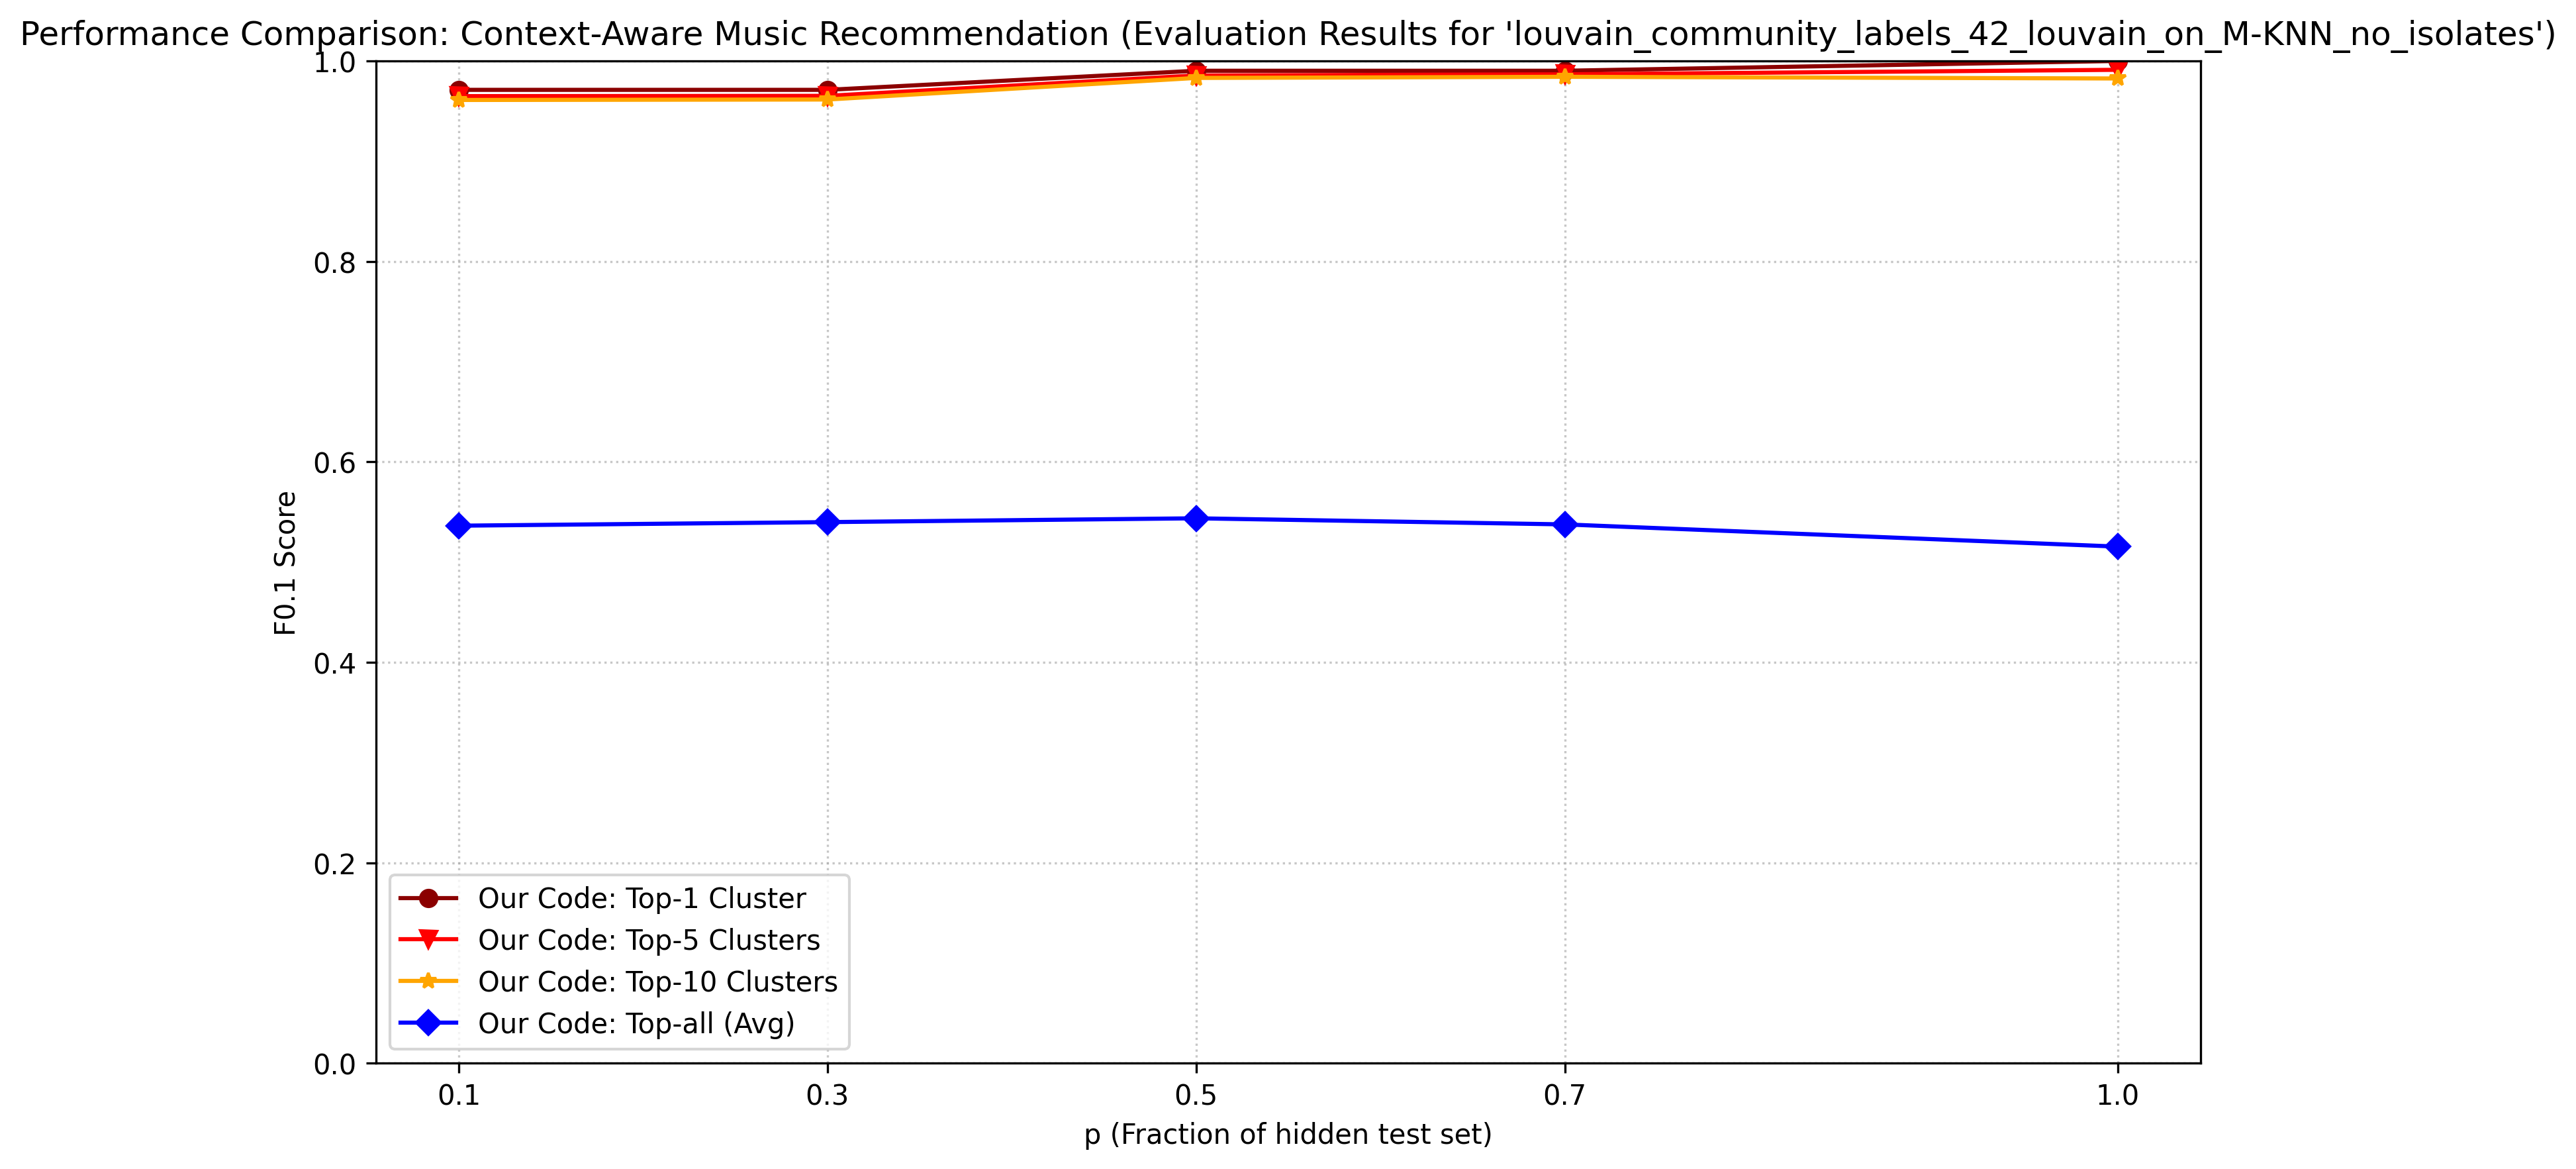

Defining $k$ hence presents a delicate trade-off. While driving $k$ toward infinity creates perfectly homogenous clusters, creating clusters that are too small effectively breaks the collaborative filter, as there are no longer enough neighbouring playlists to draw track recommendations from. Therefore, in the domain of music context discovery, the number of clusters should likely not be dictated by a global variance formula like WCSS. Instead, $k$ must emerge naturally from local topological densities, finding balance between semantic cohesion and sufficient collaborative utility.


### Conclusion
<!-- What is hidden in the playlist name? -->
The answer to the question, "what is hidden in the playlist name?" is fundamentally nuanced. Throughout this process, we expanded and in many instances improved upon the results presented in Pichl et al. While they demonstrated that a playlist title-based clustering approach improves recommendation accuracy over a standard collaborative filtering baseline, our exploration of data representation and clustering algorithms proved that this argument can be made even more robust. However, the key takeaways the authors present, especially in terms of inconsistent cluster contexts, point towards a systematic problem with this approach. While there is information that can be utilised to improve a recommendation approach, it is user generated and hence in many cases ambiguous or inane. As demonstrated in phase 3, this results in clusters where the underlying song content cannot provide meaningful rules, and demonstrates that semantic similarity in text does not guarantee deterministic musical alignment. To create a truly useful recommender system than takes into account playlist names, future architectures must move towards multimodal learning frameworks. By co-embedding the titles, raw audio features, and other user metadata, into a single shared latent space, a model would have the necessary information to bridge the gap between user intent and musical reality.

## References

Pichl, M., Zangerle, E., & Specht, G. (2015). Towards a context-aware music recommendation approach: What is hidden in the playlist name? In *2015 IEEE International Conference on Data Mining Workshop (ICDMW)* (pp. 1360–1365). IEEE. https://doi.org/10.1109/ICDMW.2015.145

Traag, V. A., Waltman, L., & van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports, 9*(1), 5233. https://doi.org/10.1038/s41598-019-41695-z

Landauer, T. K., & Dumais, S. T. (1997). A solution to Plato’s problem: The latent semantic analysis theory of acquisition, induction, and representation of knowledge. *Psychological Review, 104*(2), 211–240. https://doi.org/10.1037/0033-295X.104.2.211

Banerjee, A. (2024). Pros and cons of collaborative filtering. *Medium*. https://medium.com/@ashmi_banerjee/pros-and-cons-of-collaborative-filtering-9c3aa4ce44f6

Kaminskas, M., & Bridge, D. (2016). Diversity, serendipity, novelty, and coverage: A survey and empirical analysis of beyond-accuracy objectives in recommender systems. *ACM Transactions on Interactive Intelligent Systems, 7*(1), 1–42. https://doi.org/10.1145/2926720


## Declaration of use of GAI tools
We have used the following generative artificial intelligence (GAI) to complete this project:
- Gemini 3.1 pro

We used GAI tools in the following way:
- Support with python syntax, optimization, comments, and debugging.
- Assisted in refining text for conciseness and clarity.